In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import time
import matplotlib.pyplot as plt

## 数据预处理

In [ ]:
df_close = pd.read_csv("data/CLOSE.csv") # 收盘价
df_sh_mkt = pd.read_csv("data/Shareholder Value Market Value.csv") # 市值（万）
df_asset = pd.read_csv("data/TOT_ASSETS.csv") # 总资产
df_liab = pd.read_csv("data/TOT_LIAB.csv") # 总负债

In [3]:
# 修改列名
df_close.rename(columns={'Unnamed: 0':'stk_idx','S_DQ_ADJCLOSE':'adj_close','S_INFO_WINDCODE':'stk_code','TRADE_DT':'date'},inplace=True)
df_sh_mkt.rename(columns={'Unnamed: 0':'stk_idx','S_VAL_MV':'shareholder market value','S_INFO_WINDCODE':'stk_code','TRADE_DT':'date'},inplace=True)
df_asset.rename(columns={'Unnamed: 0':'stk_idx','TOT_ASSETS':'asset','S_INFO_WINDCODE':'stk_code','TRADE_DT':'date'},inplace=True)
df_liab.rename(columns={'Unnamed: 0':'stk_idx','TOT_LIAB':'liablity','S_INFO_WINDCODE':'stk_code','TRADE_DT':'date'},inplace=True)

# 修改日期格式
df_close['date'] = pd.to_datetime(df_close['date'].astype(str),format='%Y%m%d')
df_sh_mkt['date'] = pd.to_datetime(df_sh_mkt['date'].astype(str), format='%Y%m%d')
df_asset['date'] = pd.to_datetime(df_asset['date'].astype(str), format='%Y%m%d')
df_liab['date'] = pd.to_datetime(df_liab['date'].astype(str), format='%Y%m%d')

In [4]:
# 对收盘价以及市值进行处理
# 排序
df_close.sort_values(by=['stk_code','date'],inplace=True)

# 合并数据集
df_close_val = pd.merge(df_close[['stk_code','date','adj_close']],\
                        df_sh_mkt[['stk_code','date','shareholder market value']],how='left',on=['stk_code','date'])
# 计算总股本=市值/收盘价
df_close_val['shares'] = df_close_val['shareholder market value']*10000/df_close_val['adj_close']
# 向前填充总股本，如仍有缺失再向后填充总股本
df_close_val['shares'] = df_close_val.groupby('stk_code')['shares'].fillna(method='ffill').fillna(method='bfill')
df_close_val['shareholder market value'] = df_close_val['shareholder market value'].fillna(df_close_val['shares'] * df_close_val['adj_close'])
df_close_val

,stk_code,date,adj_close,shareholder market value,shares
0,000001.SZ,2021-09-01,2001.1600,3.469769e+11,1.733879e+08
1,000001.SZ,2021-09-02,2059.3600,3.570681e+11,1.733879e+08
2,000001.SZ,2021-09-03,2019.0700,3.500823e+11,1.733879e+08
3,000001.SZ,2021-09-06,2064.9600,3.580390e+11,1.733879e+08
4,000001.SZ,2021-09-07,2153.3800,3.733700e+11,1.733879e+08
...,...,...,...,...,...
2424891,873593.BJ,2023-08-28,68.7405,3.229962e+05,4.698776e+07
2424892,873593.BJ,2023-08-29,81.5565,3.832159e+05,4.698778e+07
2424893,873593.BJ,2023-08-30,77.9283,3.661680e+05,4.698781e+07
2424894,873593.BJ,2023-08-31,79.2059,3.721708e+05,4.698776e+07


In [5]:
# 计算月度收益率
month_end_prices = df_close_val[['stk_code','date','adj_close']]\
                    .groupby(['stk_code',df_close_val['date'].dt.to_period('M')]).tail(1).copy() # 保留月末数据
month_end_prices['monthly_return'] = month_end_prices.groupby('stk_code')['adj_close'].pct_change()
month_end_prices.dropna(inplace=True)
month_end_prices = month_end_prices[month_end_prices['monthly_return'].abs()<=1.0]# 删除月度收益大于100%的异常值
month_end_prices

,stk_code,date,adj_close,monthly_return
35,000001.SZ,2021-10-29,2182.4800,0.087564
57,000001.SZ,2021-11-30,1951.9200,-0.105641
80,000001.SZ,2021-12-31,1844.4700,-0.055048
99,000001.SZ,2022-01-28,1771.7200,-0.039442
115,000001.SZ,2022-02-28,1762.7700,-0.005052
...,...,...,...,...
2424830,873593.BJ,2023-05-31,103.4300,0.581257
2424850,873593.BJ,2023-06-30,136.3400,0.318186
2424871,873593.BJ,2023-07-31,87.8900,-0.355362
2424894,873593.BJ,2023-08-31,79.2059,-0.098806


In [6]:
# 合并liability asset 数据集
df_liab.sort_values(by=['stk_code','date'],inplace=True)
df_liab_asset = pd.merge(df_liab[df_liab['stk_idx']==0],df_asset[df_asset['stk_idx']==0],how='left',on=['stk_code','date']) 
df_liab_asset.drop(['stk_idx_x','stk_idx_y'],axis=1,inplace=True)
df_liab_asset['book equity'] = df_liab_asset['asset'] - df_liab_asset['liablity'] #计算book equity
df_liab_asset

,stk_code,liablity,date,asset,book equity
0,000001.SZ,4.464216e+12,2021-10-21,4.853074e+12,3.888580e+11
1,000001.SZ,4.525932e+12,2022-03-10,4.921380e+12,3.954480e+11
2,000001.SZ,4.711774e+12,2022-04-27,5.117949e+12,4.061750e+11
3,000001.SZ,4.696678e+12,2022-08-18,5.108776e+12,4.120980e+11
4,000001.SZ,4.769749e+12,2022-10-25,5.195133e+12,4.253840e+11
...,...,...,...,...,...
586,A22290.SZ,2.232350e+08,2023-01-28,7.366373e+08,5.134023e+08
587,A22292.SZ,1.033665e+08,2023-01-29,1.931049e+08,8.973840e+07
588,A22388.SZ,2.147759e+08,2022-11-27,7.143410e+08,4.995651e+08
589,A22562.BJ,6.493223e+07,2022-09-10,1.274868e+08,6.255462e+07


In [7]:
#保留季末数据
df_close_val.reset_index(inplace=True)

sh_mkt_end = df_close_val[['date','stk_code','shareholder market value']]\
                    .groupby(['stk_code',df_close_val['date'].dt.to_period('Q')]).tail(1).copy()
df_liab_asset_end = df_liab_asset[['date','stk_code','book equity']]\
                    .groupby(['stk_code',df_liab_asset['date'].dt.to_period('Q')]).tail(1).copy()
sh_mkt_end['y-q'] = sh_mkt_end['date'].dt.to_period('Q')
df_liab_asset_end['y-q'] = df_liab_asset_end['date'].dt.to_period('Q')

#合并
merged_data = pd.merge(sh_mkt_end[['stk_code','shareholder market value','y-q']],\
                       df_liab_asset_end[['stk_code','book equity','y-q']],on=['stk_code','y-q'],how='left')
merged_data.fillna(method='ffill',inplace=True) # book equity 向前赋值
merged_data.dropna(inplace=True) # 删除为nan的值
merged_data = merged_data[merged_data['book equity'] >= 0] # 删除book equity小于0的异常值
merged_data

,stk_code,shareholder market value,y-q,book equity
1,000001.SZ,3.198084e+11,2021Q4,3.888580e+11
2,000001.SZ,2.984630e+07,2022Q1,3.954480e+11
3,000001.SZ,2.907007e+07,2022Q2,4.061750e+11
4,000001.SZ,2.297661e+07,2022Q3,4.120980e+11
5,000001.SZ,2.553819e+07,2022Q4,4.253840e+11
...,...,...,...,...
45208,873593.BJ,6.924102e+05,2022Q3,1.861737e+07
45209,873593.BJ,6.924102e+05,2022Q4,1.861737e+07
45210,873593.BJ,6.924102e+05,2023Q1,1.861737e+07
45211,873593.BJ,6.406140e+05,2023Q2,1.861737e+07


## 构建 fama french 三因子

In [8]:
# 市场因子
def mkt_factor(date_range, df_mv, df_mo_ret):
    '''
    根据市值加权求月度市场回报率，适用于季度调仓
    注意调仓开始于date_range的第一个季度，结束于date_range的倒数第二个季度
    date_range: 用于计算因子的日期范围，季度数据
    df_mv: dataframe包括列名: year-quarter, stk_code, shareholder market value
    df_mo_ret: dataframe包括列名: date, stk_code, monthly_return
    '''
    mkt_ret = {}

    for i in range(len(date_range)-1):
        # 创建每季度市值的df
        df_temp1 = df_mv[df_mv['y-q']==date_range[i].to_period('Q')].copy()

        # 根据上期（上个季度）的市值估算当前三个月的市场回报率
        sub_date_range = pd.date_range(date_range[i],date_range[i+1],freq='M')
        for j in range(len(sub_date_range)-1):
            df_temp2 = df_mo_ret[(df_mo_ret['date']>sub_date_range[j]) & (df_mo_ret['date']<=sub_date_range[j+1])].copy()
            df_temp1 = df_temp1.merge(df_temp2[['stk_code','monthly_return']],on='stk_code',how='inner') # inner merge后才能进行算权重
            df_temp1['weight'] = df_temp1['shareholder market value'] / df_temp1['shareholder market value'].sum()
            ret = np.sum(df_temp1['weight'] * df_temp1['monthly_return'])
            # 减去无风险收益率rf=0.1241%
            mkt_ret[sub_date_range[j+1]] = ret-0.001241
            df_temp1.drop('monthly_return',axis=1,inplace=True) #防止反复merge monthly return到df_temp1
            
    return mkt_ret

date_range = pd.date_range('2021-09-30', '2023-09-30', freq='Q')
mkt_ret = mkt_factor(date_range,\
                     merged_data[['y-q','stk_code','shareholder market value']],\
                     month_end_prices[['date','stk_code','monthly_return']])


In [9]:
# SMB HML因子 双排序
def smb_hml_factor(date_range, df_mv_bq, df_mo_ret):
    '''
    分组后市值加权求smb，hml因子月度收益率，适用于季度调仓
    注意调仓开始于date_range的第一个季度，结束于date_range的倒数第二个季度
    date_range: 用于计算因子的日期范围，季度数据
    df_mv_bq: dataframe包括列名: year-quarter, stk_code, shareholder market value, book equity
    df_mo_ret: dataframe包括列名: date, stk_code, monthly_return
    '''
    smb_ret={}
    hml_ret={}

    for i in range(len(date_range)-1):
        # 创建每季度的df
        df_temp1 = df_mv_bq[df_mv_bq['y-q']==date_range[i].to_period('Q')].copy()

        sub_date_range = pd.date_range(date_range[i],date_range[i+1],freq='M')
        for j in range(len(sub_date_range)-1):
            df_temp2 = df_mo_ret[(df_mo_ret['date']>sub_date_range[j]) & (df_mo_ret['date']<=sub_date_range[j+1])].copy()
            df_temp1 = df_temp1.merge(df_temp2[['stk_code','monthly_return']],on='stk_code',how='inner') #inner merge后才能进行排序

            # size和grow独立双排序
            df_temp1['size'] = pd.qcut(df_temp1['shareholder market value'], q=[0,0.5,1],labels=['s','b'])
            df_temp1['b/m'] = df_temp1['book equity'] / df_temp1['shareholder market value']
            df_temp1['grow'] = pd.qcut(df_temp1['b/m'],q=[0,0.3,0.7,1],labels=['l','n','h'])

            # 求当期的权重
            df_temp1['weight'] = df_temp1.groupby(['size','grow'])['shareholder market value'].transform(lambda x: x/x.sum())

            # 算每个组合的收益率
            df_temp1['weighted return'] = df_temp1['weight'] * df_temp1['monthly_return']
            df_ret = df_temp1.groupby(['size','grow'])['weighted return'].sum().reset_index()
            smb = df_ret[df_ret['size'] == 's']['weighted return'].mean() - df_ret[df_ret['size'] == 'b']['weighted return'].mean()
            hml = df_ret[df_ret['grow'] == 'h']['weighted return'].mean() - df_ret[df_ret['grow'] == 'l']['weighted return'].mean()

            smb_ret[sub_date_range[j+1]] = smb
            hml_ret[sub_date_range[j+1]] = hml
            df_temp1.drop('monthly_return',axis=1,inplace=True)
    
    return smb_ret, hml_ret

smb_ret, hml_ret = smb_hml_factor(date_range, \
                                  merged_data[['y-q','stk_code','shareholder market value','book equity']], \
                                  month_end_prices[['date','stk_code','monthly_return']]) 

df_factor = pd.DataFrame([mkt_ret, hml_ret, smb_ret]).T
df_factor.columns = ['rmrf','hml','smb']
df_factor = df_factor.reset_index().rename(columns={'index':'date'})
df_factor.head()

,date,rmrf,hml,smb
0,2021-10-31,-0.016497,-0.025658,0.009029
1,2021-11-30,0.012399,0.009849,0.100319
2,2021-12-31,0.018965,0.023926,-0.005533
3,2022-01-31,-0.076117,0.021940,-0.029249
4,2022-02-28,0.031163,0.002044,0.018337


## 构造因子：残差动量、时间序列动量

### 注意此部分构建残差动量因子的时候，由于数据量不足，将regression用的样本量从36减到6

In [10]:
# 获取残差动量因子   
def ff3_mom(df_ret, df_factor, reg_length=36, mom_length=11):
    '''
    df_ret: dataframe包括列名: stk_code, date(ymd), monthly_return
    df_factor: dataframe包括列名: date(ymd), rmrf, hml, smb
    reg_length: 用于CAPM回归的样本长度，默认为36月
    mom_length: 用于计算残余动量因子的样本长度，默认为11月
    '''
    # 1. 获取回归后的残差df_residual, 包括列：date, stk_code, residual
    df_ret = df_ret.copy()
    df_factor = df_factor.copy()
    df_ret['date'] = df_ret['date']+pd.offsets.MonthEnd(0)
    df_factor['date'] = df_factor['date']+pd.offsets.MonthEnd(0)
    
    if len(df_ret['date'].dt.to_period('M').unique()) < reg_length: # 如果数据不够回归，则改变回归的样本量，仅限测试
        reg_length = 6

    df_merge = pd.merge(df_ret[['stk_code','monthly_return','date']] ,\
                        df_factor[['rmrf','hml','smb','date']],on=['date'],how='inner')
    df_merge.sort_values(by=['stk_code','date'],inplace=True)
    df_merge.set_index('date',inplace=True)
    
    # 完整化月度范围，没有数据的月份填充为nan，这样可以避免rolling的window跳过几个月份的情况
    resampled = df_merge.groupby('stk_code')\
                        .resample('1M').mean()\
                        .reset_index(level=['stk_code','date'])
    
    
    # 筛选出样本量大于reg_length的股票代码，防止RollingOLS报错
    df_size = resampled.groupby('stk_code').apply(lambda x:len(x)).reset_index()
    idx = df_size.loc[df_size.iloc[:,1]>=reg_length,'stk_code']
    resampled = resampled[resampled['stk_code'].isin(idx)]
    
    # 获取CAPM回归的系数
    rolling_beta = resampled.groupby('stk_code')\
                        .apply(lambda x: RollingOLS(endog=x['monthly_return'],\
                                                    exog=sm.add_constant(x[['rmrf','hml','smb']]),\
                                                    window=reg_length, min_nobs=5).fit().params)
    rolling_beta.reset_index(level='stk_code',drop=True,inplace=True)
    rolling_beta.rename(columns={'rmrf':'rmrf_beta','hml':'hml_beta','smb':'smb_beta'},inplace=True)
    
    #获取因子的预期收益率
    rolling_mean = resampled[['date','stk_code','rmrf','hml','smb']].groupby('stk_code')\
                        .rolling(window=reg_length, min_nobs=5)\
                        .mean().reset_index(level='stk_code',drop=True)
    
    rolling_mean.rename(columns={'rmrf':'rmrf_mean','hml':'hml_mean','smb':'smb_mean'},inplace=True)
    
    # 合并，求residual
    result = pd.concat([resampled[['date','stk_code','monthly_return']],\
                        rolling_beta,\
                        rolling_mean], axis=1)
    
    shift_col=['hml_mean','smb_mean','rmrf_mean','hml_beta','smb_beta','rmrf_beta','const']
    result[shift_col] = result.groupby('stk_code')[shift_col].shift(1)
   
    result['residual'] = result['hml_beta'] * result['hml_mean']\
                        +result['smb_beta'] * result['smb_mean']\
                        +result['rmrf_beta'] * result['rmrf_mean']\
                        +result['const']\
                        -result['monthly_return']
   
    df_residual = result[['date','stk_code','residual']].copy()
    
    # 2. 计算残差动量，t-12 - t-2
    rolling_res_sum = df_residual.groupby('stk_code')\
                                    .rolling(window=mom_length, min_nobs=6)\
                                    .sum().reset_index(level='stk_code')
    rolling_res_sum.rename(columns={'residual':'residual sum'},inplace=True)
    
    rolling_res_var = df_residual.groupby('stk_code')\
                                    .rolling(window=mom_length, min_nobs=6)\
                                    .var().reset_index(level='stk_code')
    rolling_res_var.rename(columns={'residual':'residual var'},inplace=True)
    
    df_residual = pd.concat([df_residual,\
                             rolling_res_sum['residual sum'],\
                             rolling_res_var['residual var']],axis=1)
    
    df_residual[['residual sum','residual var']] = df_residual.groupby('stk_code')[['residual sum','residual var']].shift(2)
    df_residual['residual mom'] = df_residual['residual sum']\
                                    / np.sqrt(df_residual['residual var'])
    df_residual.dropna(inplace=True)
    df_residual.reset_index(drop=True,inplace=True)
    return df_residual[['date','stk_code','residual mom']]


In [11]:
# 时间序列动量因子
def ts_mom(df_ret, delta=0.3, roll_window=11):
    '''
    df_ret: dataframe包括列名: stk_code, date(ymd), monthly_return
    delta: hyperparameter
    '''
    #1. 构建r_hat dataframe
    df_ret = df_ret.copy()
    df_ret['date'] = df_ret['date']+pd.offsets.MonthEnd(0) # 调整每月的唯一日期至月末数据，以便处理
    df_ret.set_index('date',inplace=True)
    
    # 完整化月度范围
    df_ret = df_ret.groupby('stk_code')\
                    .resample('1M').mean()\
                    .reset_index(level='stk_code')\
                    .reset_index(level='date')

    def moving_avg(window,delta):
        n = len(window)
        log_weights = np.arange(n) * np.log(delta) + np.log(1 - delta)
        weights = np.exp(log_weights)
        return np.nansum(window * weights)
        
    ret_bar = df_ret.groupby('stk_code')['monthly_return']\
                    .expanding()\
                    .apply(lambda x: moving_avg(x,delta) )\
                    .reset_index(level='stk_code')
    ret_bar.rename(columns={'monthly_return':'ret_bar'},inplace=True)
    
    df_ret = pd.concat([df_ret,ret_bar['ret_bar']],axis=1)
    df_ret['r_hat'] = df_ret['monthly_return'] - df_ret['ret_bar']
    df_rhat = df_ret[['stk_code','date','r_hat']].copy()
    
    #2. 构建 ts mom dataframe
    df_rhat['r_hat_1'] = df_rhat.groupby('stk_code')['r_hat'].shift(1)
    
    rhat_sum = df_rhat.groupby('stk_code')['r_hat_1']\
                        .rolling(window=roll_window,min_nobs=6)\
                        .sum().reset_index(level='stk_code')
    rhat_sum.rename(columns={'r_hat_1':'r_hat_sum'},inplace=True)
    
    def moving_sqr(window,delta):
        n = len(window)
        log_weights = np.arange(n) * np.log(delta) + np.log(1 - delta)
        weights = np.exp(log_weights)
        return np.nansum(window**2 * weights) # 避免nan元素导致的求和为nan

    sigma_sqr = df_rhat.groupby('stk_code')['r_hat_1']\
                .expanding()\
                .apply(lambda x: moving_sqr(x,delta))\
                .reset_index(level='stk_code')
    sigma_sqr.rename(columns={'r_hat_1':'sigma square'},inplace=True)
    
    df_rhat = pd.concat([df_rhat,rhat_sum['r_hat_sum'],sigma_sqr['sigma square']],axis=1)
    N = 12
    df_rhat['ts mom'] = np.sign(df_rhat['r_hat_sum']/N) * (df_rhat['r_hat']) / np.sqrt(df_rhat['sigma square'])
    df_ts_mom = df_rhat[['date','stk_code','ts mom']].copy()
    df_ts_mom.dropna(inplace=True)
    df_ts_mom.reset_index(drop=True,inplace=True)
    return df_ts_mom


In [12]:
# 代入数据构造因子
df_ret = month_end_prices.copy()
df_ret['monthly_return'] = df_ret['monthly_return']-0.001241 # 无风险利率为0.1241%
print('Total number of stocks',len(df_ret['stk_code'].unique()))

print('Calculate the residual mommentum')
start = time.time()
df_mom_factor = ff3_mom(df_ret, df_factor)
time1 = time.time() - start
print(df_mom_factor.head(5))
print('Total amount of time used:',time1)

print('Calculate the time series momentum')
start = time.time()
df_ts_mom_factor = ts_mom(df_ret)
time1 = time.time() - start
print(df_ts_mom_factor.head(5))
print('Total amount of time used:',time1)

Total number of stocks 5358
Calculate the residual mommentum
        date   stk_code  residual mom
0 2023-04-30  000001.SZ     -1.689811
1 2023-05-31  000001.SZ     -0.645311
2 2023-06-30  000001.SZ     -0.795620
3 2023-07-31  000001.SZ      0.723012
4 2023-08-31  000001.SZ     -0.240163
Total amount of time used: 88.80355501174927
Calculate the time series momentum
        date   stk_code    ts mom
0 2022-09-30  000001.SZ  2.610193
1 2022-10-31  000001.SZ  3.969653
2 2022-11-30  000001.SZ -5.538802
3 2022-12-31  000001.SZ  0.610541
4 2023-01-31  000001.SZ -2.562192
Total amount of time used: 122.9069995880127


## 检验因子

In [13]:
# 因子单排序
def sort_factor(df_ret, df_factor, n_groups=7, plot_fig=False):
    '''
    月度调仓构建投资组合，算因子收益率
    df_ret: dataframe包括列名: date(ymd),stk_code, monthly_return
    df_factor: dataframe包括列名: date(ymd),stk_code, 'factor_name'
    
    '''
    df_ret = df_ret.copy()
    df_factor = df_factor.copy()
    df_ret['date'] = df_ret['date']+pd.offsets.MonthEnd(0) # 调整为月末数据
    df_factor['date'] = df_factor['date']+pd.offsets.MonthEnd(0)
    df_ret.sort_values(by=['date','stk_code'],inplace=True)
    df_factor.sort_values(by=['date','stk_code'],inplace=True)
    factor_name = df_factor.columns[-1]
    
    # 合并factor以及下一期的return
    df_factor['date_lag'] = df_factor['date'] + pd.offsets.MonthEnd(1)
    df_ret.rename(columns={'date':'date_lag'},inplace=True)
    df_merge = pd.merge(df_factor[['date','date_lag','stk_code',factor_name]],\
                        df_ret[['date_lag','stk_code','monthly_return']], on=['date_lag','stk_code'], how='inner')
    
    # 每月根据因子值对股票进行分组排序（0为最小的组）
    labels = [i for i in range(n_groups)]
    df_merge['portfolio_group'] = df_merge.groupby('date')[factor_name]\
                                            .transform(lambda x: pd.qcut(x, n_groups,labels=labels) )
    # 计算每月组合的收益率（等权）
    df_merge['portfolio_return'] = df_merge.groupby(['date','portfolio_group'])['monthly_return']\
                                            .transform('mean')

    df_merge.sort_values(by=['portfolio_group','date'],inplace=True)
    df_merge.drop_duplicates(subset=['portfolio_group','date'],inplace=True)
    
    df_pfl_ret = df_merge[['date','date_lag','portfolio_group','portfolio_return']].copy()
    # 画图
    if plot_fig == True:
        plt.figure()
        
        for pfl in labels:
            pfl_ret = df_pfl_ret[df_pfl_ret['portfolio_group']==pfl].copy()
            pfl_cum_ret = (1 + pfl_ret['portfolio_return']).cumprod() - 1
            plt.plot(pfl_ret['date_lag'], pfl_cum_ret, label=pfl, linewidth=2)
        
        plt.suptitle('Portfolio Cumulative Return Comparison')
        plt.title('Factor: {}'.format(factor_name), fontsize=10, style='italic') 
        plt.ylabel('Cumulative Return')
        plt.xlabel('Date')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return df_pfl_ret


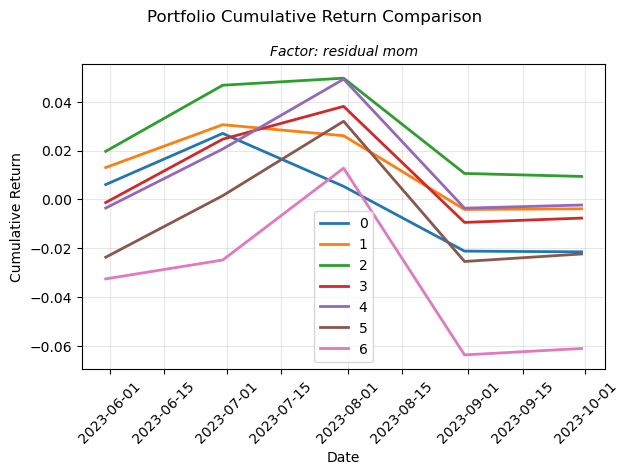

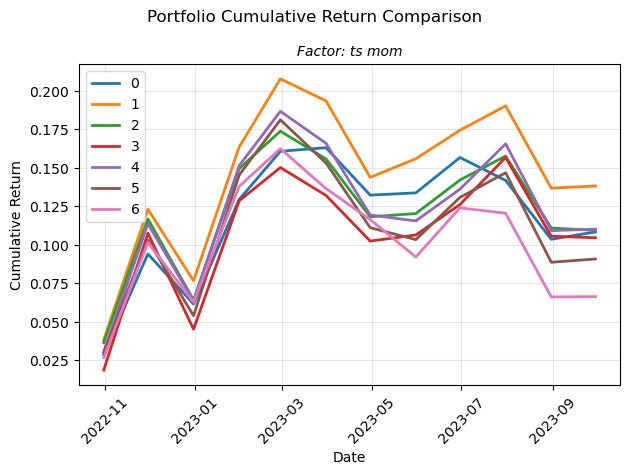

In [14]:
# 因子收益率表现结果
ff3_mom_pfl_ret = sort_factor(df_ret, df_mom_factor,plot_fig=True)
ts_mom_pfl_ret = sort_factor(df_ret, df_ts_mom_factor,plot_fig=True)

In [15]:
# 因子IC表现
# 获取IC序列
def get_factor_ic(df_ret, df_factor):
    '''
    获取因子IC
    df_ret: dataframe包括列名:date(ymd),stk_code, monthly_return
    df_factor: dataframe包括列名: date(ymd),stk_code, 'factor_name'
    '''
    df_ret = df_ret.copy()
    df_factor = df_factor.copy()
    df_ret['date'] = df_ret['date']+pd.offsets.MonthEnd(0) # 调整为月末数据
    df_factor['date'] = df_factor['date']+pd.offsets.MonthEnd(0)
    df_ret.sort_values(by=['date','stk_code'],inplace=True)
    df_factor.sort_values(by=['date','stk_code'],inplace=True)
    factor_name = df_factor.columns[-1]
    
    # 合并factor以及下一期的return
    df_factor['date_lag'] = df_factor['date'] + pd.offsets.MonthEnd(1)
    df_ret.rename(columns={'date':'date_lag'},inplace=True)
    df_merge = pd.merge(df_factor[['date','date_lag','stk_code',factor_name]],\
                        df_ret[['date_lag','stk_code','monthly_return']], on=['date_lag','stk_code'], how='inner')
    
    def cal_corr(df):
        return df.corr().iloc[0,1]
    
    df_ic = df_merge.groupby('date')[[factor_name,'monthly_return']].apply(cal_corr).reset_index()
    df_ic.columns = ['date', 'IC']
    return df_ic


# 分析IC表现
def analysis_factor_ic(df_ret, df_factor):
    '''
    df_ret: dataframe包括列名:date(ymd),stk_code, monthly_return
    df_factor: dataframe包括列名: date(ymd),stk_code, 'factor_name'
    '''
    factor_name = df_factor.columns[-1]
    df_ic = get_factor_ic(df_ret, df_factor)
    ic_mean = df_ic['IC'].mean()
    ic_std = df_ic['IC'].std()
    ir_ratio = ic_mean / ic_std
    ic0_ratio = 100 * len(df_ic.loc[df_ic['IC'] > 0, :]) / len(df_ic)
    ic002_ratio = 100 * len(df_ic.loc[df_ic['IC'] > 0.02, :]) / len(df_ic)
    
    dct = {
        '因子名称': factor_name,
        'IC均值': ic_mean,
        'IC标准差': ic_std,
        'IR比率': ir_ratio,
        'IC>0的比例(%)': ic0_ratio,
        'IC>0.02的比例(%)': ic002_ratio,
    }
    
    return dct

In [16]:
# 因子IC结果
print('Residual Momentum Factor IC Performance')
print(get_factor_ic(df_ret, df_mom_factor),'\n')
print(analysis_factor_ic(df_ret, df_mom_factor),'\n')

print('Time Series Momentum Factor IC Performance')
print(get_factor_ic(df_ret, df_ts_mom_factor),'\n')
print(analysis_factor_ic(df_ret, df_ts_mom_factor),'\n')

Residual Momentum Factor IC Performance
        date        IC
0 2023-04-30 -0.129303
1 2023-05-31 -0.013618
2 2023-06-30  0.196456
3 2023-07-31 -0.198764
4 2023-08-31  0.048560 

{'因子名称': 'residual mom', 'IC均值': -0.019334070331267356, 'IC标准差': 0.1545121155249985, 'IR比率': -0.12512980141119937, 'IC>0的比例(%)': 40.0, 'IC>0.02的比例(%)': 40.0} 

Time Series Momentum Factor IC Performance
         date        IC
0  2022-09-30 -0.013997
1  2022-10-31  0.000733
2  2022-11-30  0.008529
3  2022-12-31  0.007491
4  2023-01-31  0.031172
5  2023-02-28 -0.024744
6  2023-03-31  0.025057
7  2023-04-30 -0.024221
8  2023-05-31  0.055152
9  2023-06-30  0.035720
10 2023-07-31  0.025192
11 2023-08-31 -0.052901 

{'因子名称': 'ts mom', 'IC均值': 0.006098536098864143, 'IC标准差': 0.030790138029621758, 'IR比率': 0.19806783889689047, 'IC>0的比例(%)': 66.66666666666667, 'IC>0.02的比例(%)': 41.666666666666664} 

